In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# path = 'P:\\Lukas_Gehrke\\NAH\\behavior\\5_single-subject-EEG-analysis'
path = '/Users/lukasgehrke/data/NAH/data/5_single-subject-EEG-analysis/'
fname = 'behavior_all.csv'

df = pd.read_csv(path + fname, delimiter=';')

In [6]:
# data cleaning
# df = df[df.bad_epoch != 1]

# select only the first 5 trials of each hapticProfile
df = df.groupby(['hapticProfile', 'id']).head(10)


                     mean       std
hapticProfile                      
baseline         0.405683  0.177227
sound            0.396551  0.159786
vibration        0.524846  0.161402
vibration+sound  0.510972  0.165771


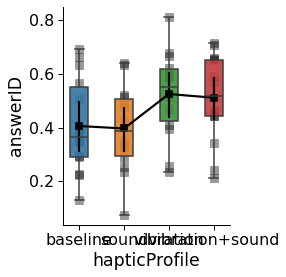

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [7]:
df = df.groupby(['hapticProfile','id']).mean().reset_index()

y = 'answerID'
title = 'answerID'

# y = 'AccuracyCm'
# title = 'AccuracyCm'

# y = 'fix_delay'

print(df.groupby('hapticProfile')[y].agg(['mean','std']))

with sns.plotting_context('paper', font_scale = 1.8):

    ### Create new plot
    fig, ax = plt.subplots(1, 1, figsize=(3,4))
    fig.patch.set_alpha(1)

    sns.despine() #bottom=True, left=True

    # Plot the orbital period with horizontal boxes
    # sns.boxplot(x=x, y=y, behavior=behavior, whis=[0, 100], width=.3, order= ['intention','involuntary','augmented'], palette=palette, linewidth=1)

    # Add in points to show each observation
    # sns.stripplot(x=x, y=y, behavior=behavior, size=6, palette=palette, linewidth=1, dodge='auto', legend=None)

    # show boxplots
    ax = sns.boxplot(data = df, x = 'hapticProfile', y = y, order= ['baseline','sound','vibration','vibration+sound'], width=.4, hue='hapticProfile', linewidth=1.5)
    for patch in ax.patches: # adapt alpha
            r, g, b, a = patch.get_facecolor()
            patch.set_facecolor((r, g, b, .9))

    # show line connecting means
    ax =  sns.pointplot(data = df, x = 'hapticProfile', y = y, markers="s" ,color = 'black', order= ['baseline','sound','vibration','vibration+sound'])
        
    #  show lines connecting pid means observations    
    # ax = sns.lineplot(data = df, x = 'hapticProfile', y = y, hue = id, palette = sns.color_palette(['black'],8),legend = False,alpha=0.4)
    
    ax = sns.scatterplot(data = df, x = 'hapticProfile', y = y, s=50, legend= True, marker="s",color = 'black',edgecolor = 'black',alpha=0.4)
        
    # ax.invert_yaxis()
    # add_stat_annotation(ax, behavior=behavior_means, x=x, y=y, box_pairs=[("baseline", "ems_random"), ("baseline", "ems_bci"), ('ems_random', 'ems_bci')], test='t-test_paired', text_format='star', loc='outside', verbose=2)

    handles, labels = ax.get_legend_handles_labels()  
    
    #plt.legend(handles[3:6],labels[3:6],frameon=True,loc = 'upper left',labelspacing =0.3)

    # set ylimit
    # ax.set_ylim(-450,150)
    
    # label_plot_for_subcats(ax)
    # ax.set_title(title)
    # ax.set_ylabel(ylabel)
    # ax.set_xlabel(xlabel)
    
    plt.show()

    fig.savefig(title + '.eps', format='eps', transparent=True, bbox_inches='tight', dpi=300)
    fig.savefig(title + '.svg', format='svg', transparent=True, bbox_inches='tight', dpi=300)
    fig.savefig(title + '.png', format='png', transparent=True, bbox_inches='tight', dpi=300)

In [8]:
import pymer4 as pymer4
from pymer4.models import Lmer

full_model = Lmer(y + " ~ hapticProfile + (1|id)", data = df)
display(full_model.fit(REML = False))

null_model = Lmer(y + " ~ (1|id)", data = df)
display(null_model.fit(REML = False))

pymer4.stats.lrt([null_model,full_model])

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: answerID~hapticProfile+(1|id)

Family: gaussian	 Inference: parametric

Number of observations: 56	 Groups: {'id': 14.0}

Log-likelihood: 38.175 	 AIC: -64.351

Random effects:

                 Name    Var    Std
id        (Intercept)  0.017  0.130
Residual               0.009  0.093

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.406,0.322,0.490,0.043,24.239,9.479,0.000,***
hapticProfilesound,-0.009,-0.078,0.060,0.035,42.000,-0.259,0.797,
hapticProfilevibration,0.119,0.050,0.188,0.035,42.000,3.381,0.002,**
hapticProfilevibration+sound,0.105,0.036,0.174,0.035,42.000,2.987,0.005,**


Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: answerID~(1|id)

Family: gaussian	 Inference: parametric

Number of observations: 56	 Groups: {'id': 14.0}

Log-likelihood: 29.270 	 AIC: -52.541

Random effects:

                 Name    Var    Std
id        (Intercept)  0.016  0.126
Residual               0.013  0.115

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.46,0.387,0.532,0.037,14.0,12.433,0.0,***


,model,npar,AIC,BIC,log-likelihood,deviance,Chisq,Df,P-val,Sig
0,answerID~(1|id),3,-52.540829,-46.464774,29.270414,-58.540829,,,,
1,answerID~hapticProfile+(1|id),6,-64.350666,-52.198556,38.175333,-76.350666,17.809837,3.0,0.000481,***
